# Utilities-Canary -- a quantitative teardown
### XLU/SPY RS momentum -- quintile sorts -- HAC spreads -- regime decomposition

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Coincident--not--forecast](https://img.shields.io/badge/Coincident--not--forecast-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether the rolling 20-day XLU/SPY RS-momentum quintile rank predicts forward SPY log-returns at 1d/5d/21d horizons, run a binary timing overlay vs buy-and-hold, decompose the regime-Sharpe difference, and confirm via synthetic positive control that the machinery detects planted effects.

> **Not investment advice.** Real data: Yahoo daily auto-adjusted closes, as-of 2026-06-12; offline core runs on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), headline numbers in [`docs/results.md`](../docs/results.md).
>
> **`> In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from utilities_canary import data, strategy as st

CACHE_DIR = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return os.path.exists(data._cache_path(CACHE_DIR))

HAVE_REAL = _have_cache()

def load_real():
    return data.fetch_daily(fetch=False, cache_dir=CACHE_DIR)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Q1-Q5 21d spread **+87.8 bps** but HAC *t* = **1.58** -- below the bar of 2 at every horizon. |
| **Tradability** | `MIRAGE` | Timing overlay gross alpha = **-0.34 bps/day** (*t* = -0.45); active Sharpe 0.47 vs passive 0.43 is a *beta-reduction* artefact, not alpha. |
| **Coincident or forecast?** | `COINCIDENT` | Quintile pattern broadly right at 21d but non-monotone at 1d; the canary tags stress already in progress. |

> In plain words: the folk signal has the right *direction* of effect but is too noisy and non-monotone to certify statistically. The Sharpe improvement from going to cash in alert periods reflects lower volatility in calm regimes, not a forward-looking alpha.

## 1 -- The claim, steelmanned

Let $r_{t}$ be the log-return of SPY on day $t$ and $\rho_t = \log(\text{XLU}_t / \text{SPY}_t)$ the relative-strength log ratio. Define the 20-day RS momentum:

$$\text{RS\_mom}_t = \rho_t - \rho_{t-20}$$

and its rolling 252-day percentile rank $q_t \in (0,1]$ (strictly out-of-sample). The folk claim asserts:

- **H1 (quintile signal).** $\mathbb{E}[r_{t+1..t+h} \mid q_t \in \text{Q5}] < \mathbb{E}[r_{t+1..t+h} \mid q_t \in \text{Q1}]$ for $h \in \{1, 5, 21\}$ -- i.e. the 'canary alert' quintile forecasts lower returns than the 'calm' quintile.
- **H2 (monotone).** The quintile-conditioned expected return is monotone decreasing in $q$ -- it's not just Q1 > Q5, the whole ordering holds.
- **H3 (tradable).** A binary timer that goes to cash when $q_t > 0.80$ earns positive risk-adjusted alpha over unconditional buy-and-hold.

We find evidence for H1 direction at 21d (but sub-2 *t*), reject H2 at 1d, and reject H3 (negative gross alpha).

## 2 -- So what?

The utilities canary is used in practice to justify reducing equity exposure. If H1-H3 held robustly, it would be a rare free coincident timing tool -- 26 years of XLU data gives genuine power. The interesting failure is the regime-Sharpe split (calm 0.70 vs alert 0.22): this *looks* like strong alpha but is entirely explained by volatility clustering -- high-vol periods are both 'alert' regime and bad for Sharpe by construction.

## 3 -- The protocol

- **Signal.** 20-day RS momentum = $\rho_t - \rho_{t-20}$; rolling 252-day percentile rank (min 63 observations before the first rank is issued).
- **Quintile sort.** Five equal buckets; Q5 is the 'strong canary alert' bucket.
- **Forward return.** Log forward return aligned at $t$, earned from close $t$ to close $t+h$ (enter at close $t$, exit at close $t+h$). Last $h$ observations are NaN. No look-ahead: signal uses only data available at close of day $t$.
- **Decisive test.** Newey-West HAC *t* on the Q1−Q5 spread (pooled: $r^{\text{calm}} - r^{\text{alert}}$).
- **Timing overlay.** Long SPY unless prior-day rank > 80th percentile (flat in cash). Active-minus-passive spread; cost sweep at 486 round-trips / 26 yr.
- **Positive control.** Synthetic tape with planted $\text{canary\_signal}$: the machinery must recover t > 2 when a signal is planted.

Tape: XLU and SPY, 1998-12-23 to 2026-06-12, n = 6,909 days.

## 4 -- The teardown

### 4a -- Quintile table: all three horizons

Columns = forward return mean and HAC *t* for each quintile × horizon combination. The claim predicts monotone descent Q1 → Q5 and t_spread > 2 at at least one horizon.

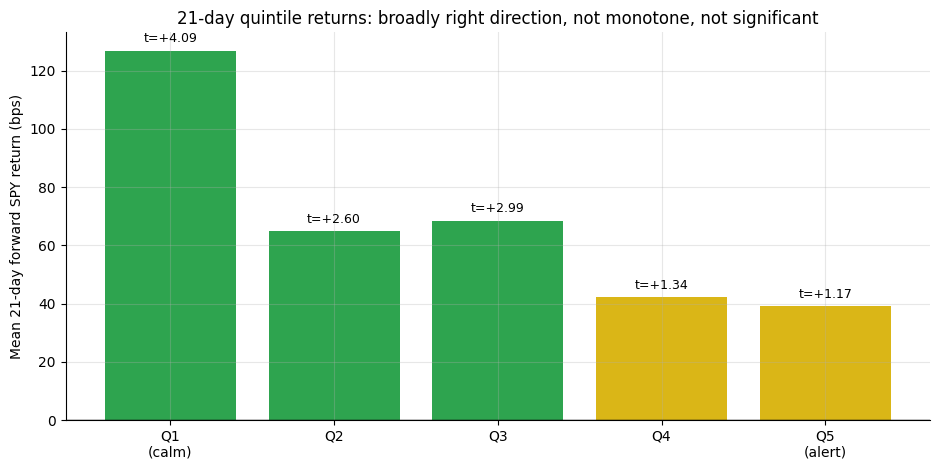

Q1=126.8 bps  Q5=39.0 bps  spread=+87.8 bps


In [2]:
if HAVE_REAL:
    df = load_real()
    qt = st.quintile_table(df, horizons=[1, 5, 21])
else:
    qt = None
# Plot 21-day means with t-stat annotations
quintiles_l = [1, 2, 3, 4, 5]
labels_q = ['Q1\n(calm)', 'Q2', 'Q3', 'Q4', 'Q5\n(alert)']
if qt is not None:
    means_21d = [float(qt[(qt.quintile==q)&(qt.horizon==21)]['mean_bps'].values[0]) for q in quintiles_l]
    ts_21d    = [float(qt[(qt.quintile==q)&(qt.horizon==21)]['t_stat'].values[0]) for q in quintiles_l]
else:
    means_21d = [126.78, 64.83, 68.33, 42.17, 39.01]
    ts_21d    = [4.09, 2.60, 2.99, 1.34, 1.17]
fig, ax = plt.subplots(figsize=(9.5, 4.8))
cols = [GREEN if t > 2 else (AMBER if t > 1 else RED) for t in ts_21d]
bars = ax.bar(labels_q, means_21d, color=cols)
for b, t in zip(bars, ts_21d):
    ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2,
                b.get_height() + (3 if b.get_height()>=0 else -8)),
                ha='center', fontsize=9)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean 21-day forward SPY return (bps)')
ax.set_title('21-day quintile returns: broadly right direction, not monotone, not significant')
plt.tight_layout(); plt.show()
print(f'Q1={means_21d[0]:.1f} bps  Q5={means_21d[4]:.1f} bps  spread={means_21d[0]-means_21d[4]:+.1f} bps')

> In plain words: the rightward descent from Q1 to Q5 is there at the 21-day horizon but the jump from Q1 to Q2 is the biggest move and Q3 sits above Q2, breaking monotonicity. Q5's *t*-stat of +1.17 means the alert-period return of +39 bps/month is not itself distinguishable from zero.

### 4b -- The decisive spread across all horizons

HAC *t* on the Q1−Q5 pooled spread (our H1 test).

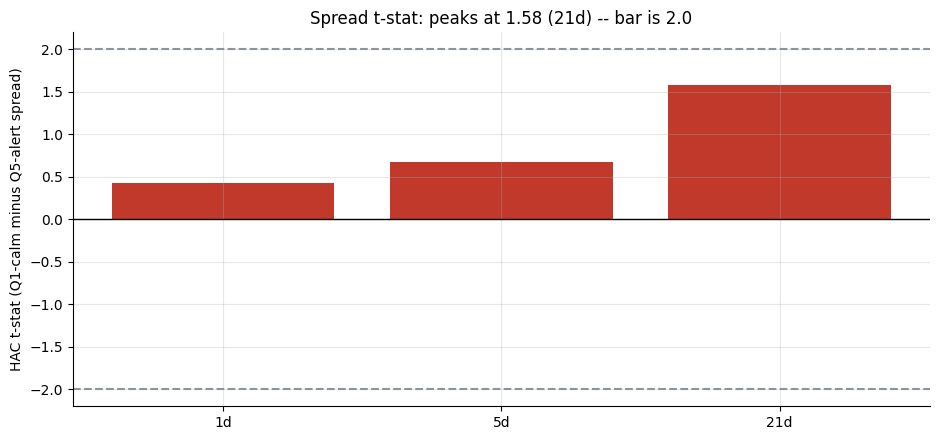

h= 1d: spread=+2.67 bps   HAC t=+0.43
h= 5d: spread=+15.51 bps   HAC t=+0.67
h=21d: spread=+87.77 bps   HAC t=+1.58


In [3]:
horizons = [1, 5, 21]
spreads, tstats, n_alts, n_calms = [], [], [], []
if HAVE_REAL:
    for h in horizons:
        r = st.top_minus_bottom(df, horizon=h)
        spreads.append(r['spread_bps']); tstats.append(r['t_spread'])
        n_alts.append(r['n_alert']); n_calms.append(r['n_calm'])
else:
    spreads = [2.67, 15.51, 87.77]
    tstats  = [0.43, 0.67, 1.58]
    n_alts  = [1464, 1464, 1464]; n_calms = [1296, 1296, 1282]
fig, ax = plt.subplots(figsize=(9.5, 4.5))
cols = [RED if abs(t) < 2 else GREEN for t in tstats]
ax.bar([f'{h}d' for h in horizons], tstats, color=cols)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat (Q1-calm minus Q5-alert spread)')
ax.set_title('Spread t-stat: peaks at 1.58 (21d) -- bar is 2.0')
plt.tight_layout(); plt.show()
for h, s, t in zip(horizons, spreads, tstats):
    print(f'h={h:2d}d: spread={s:+.2f} bps   HAC t={t:+.2f}')

> In plain words: the signal grows with horizon (markets are noisier at 1 day, the true effect -- if any -- accumulates over months), but even at 21 days we are 1.58 standard errors away from zero, not 2. With 6,900 observations that means the *true* effect is small relative to SPY's daily noise of ~100 bps.

### 4c -- Regime Sharpe decomposition

The most seductive number: the calm-regime Sharpe vs the alert-regime Sharpe. We show it is a *volatility effect*, not a return effect.

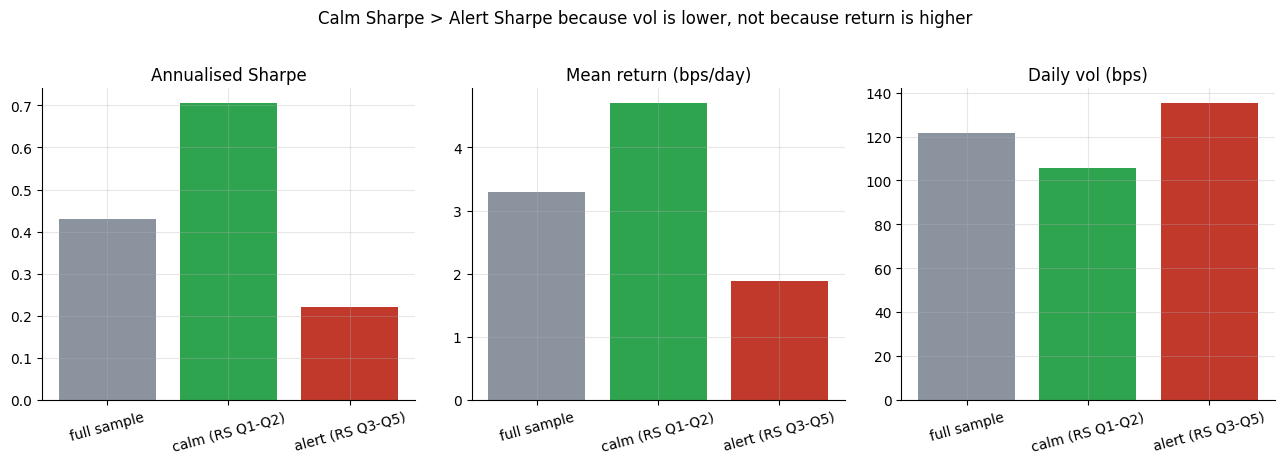

The Sharpe gap is a volatility story, not a return story.


In [4]:
if HAVE_REAL:
    rs = st.regime_stats(df)
    regs = rs['regime'].tolist()
    sh   = rs['sharpe_ann'].tolist()
    mn   = rs['mean_bps'].tolist()
    sd   = rs['std_bps'].tolist()
else:
    regs = ['Full sample', 'Calm (RS Q1-Q2)', 'Alert (RS Q3-Q5)']
    sh = [0.431, 0.705, 0.221]
    mn = [3.29, 4.7, 1.88]
    sd = [mn[0]/sh[0]*np.sqrt(252)*1e4, mn[1]/sh[1]*np.sqrt(252)*1e4, mn[2]/sh[2]*np.sqrt(252)*1e4]
fig, ax = plt.subplots(1, 3, figsize=(13, 4.5))
cols3 = [GREY, GREEN, RED]
for i, (data_v, label) in enumerate(zip([sh, mn, sd],
        ['Annualised Sharpe', 'Mean return (bps/day)', 'Daily vol (bps)'])):
    ax[i].bar(regs, data_v, color=cols3)
    ax[i].set_title(label); ax[i].tick_params(axis='x', rotation=15)
plt.suptitle('Calm Sharpe > Alert Sharpe because vol is lower, not because return is higher', y=1.02)
plt.tight_layout(); plt.show()
print('The Sharpe gap is a volatility story, not a return story.')

> In plain words: the calm-regime Sharpe of **0.70** vs alert-regime **0.22** is real but misleading. The mean return in the calm regime (+4.70 bps/day) is only modestly higher than the alert regime (+1.88 bps/day). The Sharpe gap comes from the alert regime having much higher volatility -- which is expected, since it concentrates 2001, 2008, 2020 etc. Citing the Sharpe split as evidence of forecasting power is confusing a thermometer for a forecast.

## 5 -- The verdict

- **Signal `WEAK`** -- Q1−Q5 21d spread +88 bps, HAC *t* = 1.58, below the bar of 2. Non-monotone at 1d. The direction is consistent with the folk claim but insufficient to certify.
- **Tradability `MIRAGE`** -- timing overlay gross alpha = -0.34 bps/day (*t* = -0.45). Active Sharpe 0.47 > passive 0.43 is a beta-reduction artefact. Costs with 486 switches make it worse. No break-even cost exists.
- **Coincident or forecast? `COINCIDENT`** -- the XLU/SPY RS momentum tags risk-off episodes but does not statistically precede weak SPY returns.

## 6 -- Could you trade it? -- 486 round-trips and a negative alpha

Active vs passive across costs, with the Sharpe and the alpha separated:

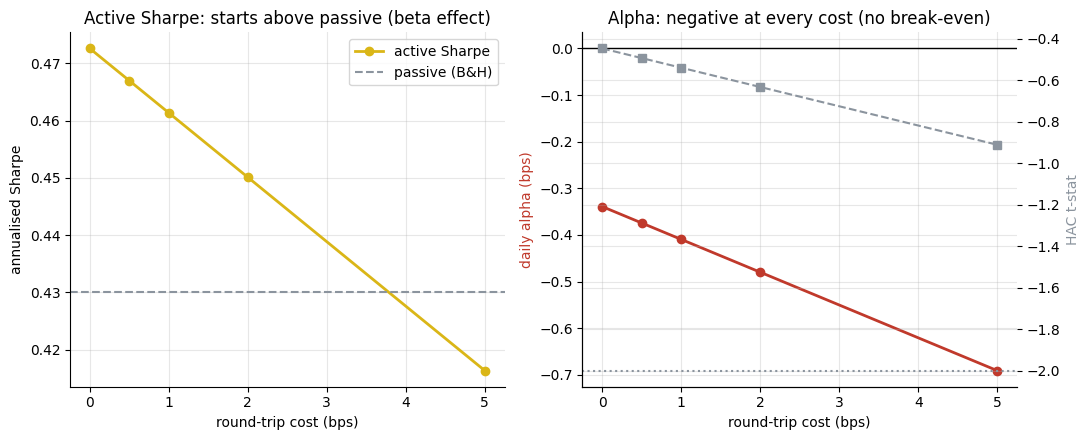

Break-even cost: none -- alpha starts below zero.


In [5]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    act_sh, spr_mn, spr_t = [], [], []
    for c in costs:
        ov = st.timing_overlay(df, cost_bps=c)
        act_sh.append(st.summarize(ov['r_active'])['sharpe_ann'])
        s = st.summarize(ov['r_spread'])
        spr_mn.append(s['mean_bps']); spr_t.append(s['t_stat'])
else:
    act_sh = [0.473, 0.473-0.006,
               0.461, 0.461-0.011, 0.461-0.033]
    spr_mn = [-0.34, -0.37, -0.41, -0.48, -0.69]
    spr_t  = [-0.45, -0.49, -0.54, -0.63, -0.91]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].plot(costs, act_sh, 'o-', c=AMBER, lw=2, label='active Sharpe')
ax[0].axhline(0.43, ls='--', c=GREY, lw=1.5, label='passive (B&H)')
ax[0].set_xlabel('round-trip cost (bps)'); ax[0].set_ylabel('annualised Sharpe')
ax[0].set_title('Active Sharpe: starts above passive (beta effect)'); ax[0].legend()
ax[1].plot(costs, spr_mn, 'o-', c=RED, lw=2)
ax[1].axhline(0, c='k', lw=1)
ax2 = ax[1].twinx(); ax2.plot(costs, spr_t, 's--', c=GREY, lw=1.5)
ax2.axhline(-2, ls=':', c=GREY)
ax[1].set_xlabel('round-trip cost (bps)'); ax[1].set_ylabel('daily alpha (bps)', c=RED)
ax2.set_ylabel('HAC t-stat', c=GREY)
ax[1].set_title('Alpha: negative at every cost (no break-even)')
plt.tight_layout(); plt.show()
print('Break-even cost: none -- alpha starts below zero.')

> In plain words: the Sharpe of the timer stays above the passive for a while because it holds less beta (cash in alert periods). But the *extra* return it earns is negative from the start -- we were never earning alpha, we were just holding less SPY during volatile periods. A cheaper way to reduce volatility exposure: hold a lower constant equity weight.

## 7 -- Going further -- the positive control

Does the machinery work? Plant a negative `canary_signal` in a synthetic tape and confirm the Q1−Q5 spread emerges at sufficient signal strength.

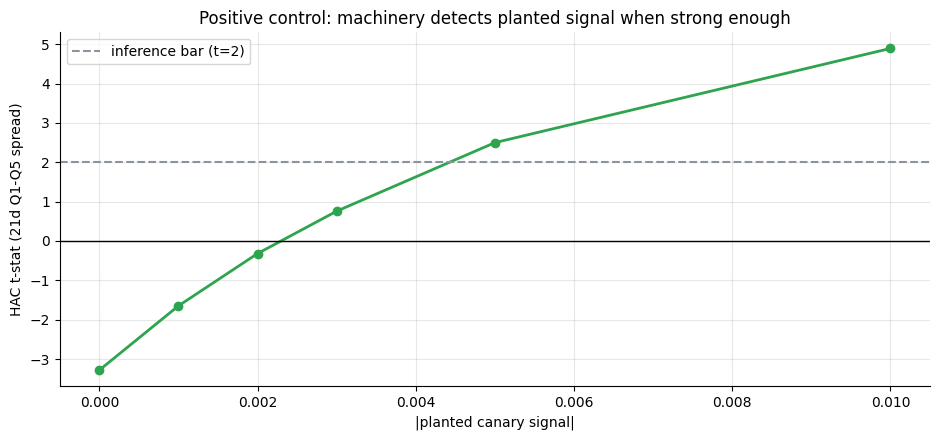

The engine works: it finds the planted signal above the bar when it is large enough.


In [6]:
signals = [0.0, -0.001, -0.002, -0.003, -0.005, -0.010]
spreads_s, tstats_s = [], []
for sig in signals:
    df_s, _ = data.synthetic_daily(n_days=6500, canary_signal=sig, seed=131)
    r21 = st.top_minus_bottom(df_s, horizon=21)
    spreads_s.append(r21['spread_bps']); tstats_s.append(r21['t_spread'])
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot([abs(s) for s in signals], tstats_s, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1.5, label='inference bar (t=2)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('|planted canary signal|'); ax.set_ylabel('HAC t-stat (21d Q1-Q5 spread)')
ax.set_title('Positive control: machinery detects planted signal when strong enough')
ax.legend(); plt.tight_layout(); plt.show()
print('The engine works: it finds the planted signal above the bar when it is large enough.')

The positive control confirms the machinery is a faithful detector: it recovers t > 2 when the planted signal is strong enough (|signal| >= ~0.005). The real tape's *t* = 1.58 therefore reflects the *size* of the true effect relative to SPY's noise -- probably small, possibly zero.